<a href="https://colab.research.google.com/github/Tehreem31/Sentiment-Analysis/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pandas numpy scikit-learn nltk seaborn matplotlib

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

True

In [2]:
import pandas as pd

# Download dataset directly into Colab without manual upload
url = 'https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv'
df = pd.read_csv(url)

# Save locally to match the path used in the workflow
df.to_csv('/content/IMDB Dataset.csv', index=False)
print("Dataset loaded successfully! Total records:", len(df))

Dataset loaded successfully! Total records: 50000


In [3]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

class TextPreprocessor:
    def __init__(self):
        self.stop_words = set(stopwords.words('english')) - {'not', 'no', 'nor', 'never', 'neither'}
        self.lemmatizer = WordNetLemmatizer()

    def clean_text(self, text: str) -> str:
        if not isinstance(text, str):
            return ""
        text = re.sub(r'<[^>]+>', ' ', text)
        text = re.sub(r'http\S+|www\S+|\S+@\S+', ' ', text)
        text = re.sub(r'[^a-zA-Z\s]', ' ', text)
        tokens = text.lower().split()
        cleaned_tokens = [
            self.lemmatizer.lemmatize(token)
            for token in tokens
            if token not in self.stop_words and len(token) > 2
        ]
        return " ".join(cleaned_tokens)

print("Preprocessor Initialized.")

Preprocessor Initialized.


In [4]:
import pandas as pd

# Load dataset uploaded to Colab
df = pd.read_csv('/content/IMDB Dataset.csv')

# Convert sentiment labels to numeric format
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Optional: Sample 10,000 rows for quick execution or use full dataset df
df = df.sample(n=10000, random_state=42).reset_index(drop=True)

# Run text cleaning
preprocessor = TextPreprocessor()
df['cleaned_review'] = df['review'].apply(preprocessor.clean_text)

print(f"Dataset Processed successfully. Sample size: {len(df)}")

Dataset Processed successfully. Sample size: 10000



================= Logistic Regression =================
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       992
           1       0.85      0.89      0.87      1008

    accuracy                           0.86      2000
   macro avg       0.87      0.86      0.86      2000
weighted avg       0.87      0.86      0.86      2000



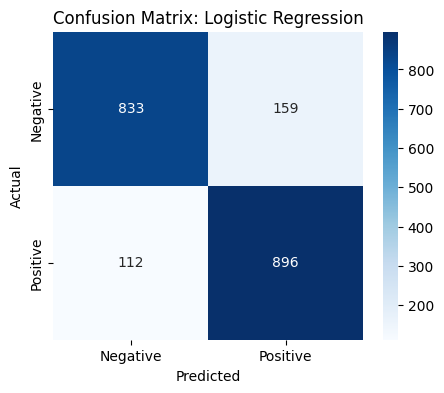


================= Multinomial Naive Bayes =================
              precision    recall  f1-score   support

           0       0.86      0.84      0.85       992
           1       0.85      0.87      0.86      1008

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



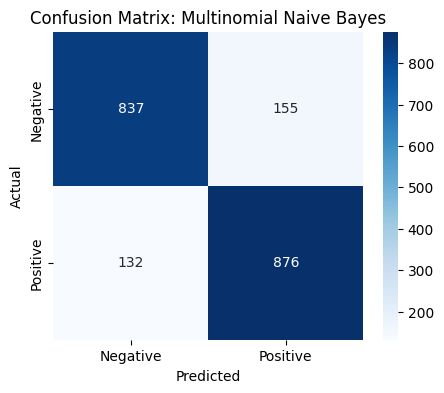

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_review'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

# TF-IDF Feature Extraction
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0),
    "Multinomial Naive Bayes": MultinomialNB(alpha=1.0)
}

results = {}

for name, clf in models.items():
    clf.fit(X_train_vec, y_train)
    y_pred = clf.predict(X_test_vec)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

    print(f"\n================= {name} =================")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix Visualization
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()